# AuthentiText: AI-Generated Essay Detection

**An NLP Classification Project to Distinguish Human-Written from AI-Generated Essays**

---

### Project Overview
With the widespread adoption of Large Language Models (LLMs) such as ChatGPT, the ability to reliably distinguish between human-written and AI-generated text has become increasingly important, particularly in academic integrity, content moderation, and publishing contexts.

This notebook builds an end-to-end NLP pipeline that:
1. Explores and cleans a labeled dataset of student essays (human vs AI-generated)
2. Engineers text-based and stylometric features
3. Trains and compares several machine learning classifiers
4. Evaluates the best model and saves it for deployment in a Streamlit web app

**Dataset:** `Training_Essay_Data.csv` — 29,145 essays labeled as:
- `0` → Human-written
- `1` → AI-generated

---

## 1. Import Libraries

In [3]:
pip install -r requirements.txt

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_events-0.12.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_server_terminals-0.5.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached send2trash-2.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached babel-2.18.0-py3-none


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import warnings
warnings.filterwarnings('ignore')

import re
import string
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Dataset

In [10]:
df = pd.read_csv('data/Training_Essay_Data.csv')
print("Shape:", df.shape)
df.head()

Shape: (29145, 2)


,text,generated
0,Car-free cities have become a subject of incre...,1
1,"Car Free Cities Car-free cities, a concept ga...",1
2,A Sustainable Urban Future Car-free cities ...,1
3,Pioneering Sustainable Urban Living In an e...,1
4,The Path to Sustainable Urban Living In an ...,1


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29145 entries, 0 to 29144
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       29145 non-null  str  
 1   generated  29145 non-null  int64
dtypes: int64(1), str(1)
memory usage: 62.6 MB


In [12]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass distribution:\n", df['generated'].value_counts())

Missing values:
 text         0
generated    0
dtype: int64

Duplicate rows: 1805

Class distribution:
 generated
0    17508
1    11637
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

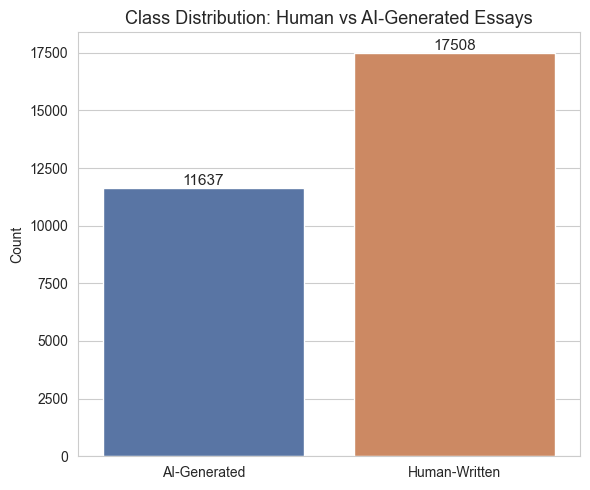

generated
0    60.072054
1    39.927946
Name: proportion, dtype: float64


In [14]:
# Class balance
label_map = {0: 'Human-Written', 1: 'AI-Generated'}
df['label'] = df['generated'].map(label_map)

plt.figure(figsize=(6,5))
ax = sns.countplot(x='label', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Class Distribution: Human vs AI-Generated Essays', fontsize=13)
plt.xlabel('')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=120)
plt.show()

print(df['generated'].value_counts(normalize=True) * 100)

In [15]:
# Text length analysis
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['avg_word_length'] = df['char_count'] / df['word_count']
df['sentence_count'] = df['text'].apply(lambda x: len(re.split(r'[.!?]+', str(x))))

df[['char_count', 'word_count', 'avg_word_length', 'sentence_count']].describe()

,char_count,word_count,avg_word_length,sentence_count
count,29145.00000,29145.000000,29145.000000,29145.000000
mean,2235.99674,383.144519,5.859394,20.032390
std,987.34624,171.845881,0.606326,9.827132
min,1.00000,1.000000,1.000000,1.000000
25%,1505.00000,263.000000,5.474409,13.000000
50%,2158.00000,351.000000,5.762901,18.000000
75%,2750.00000,474.000000,6.198113,26.000000
max,9157.00000,1650.000000,37.901316,110.000000


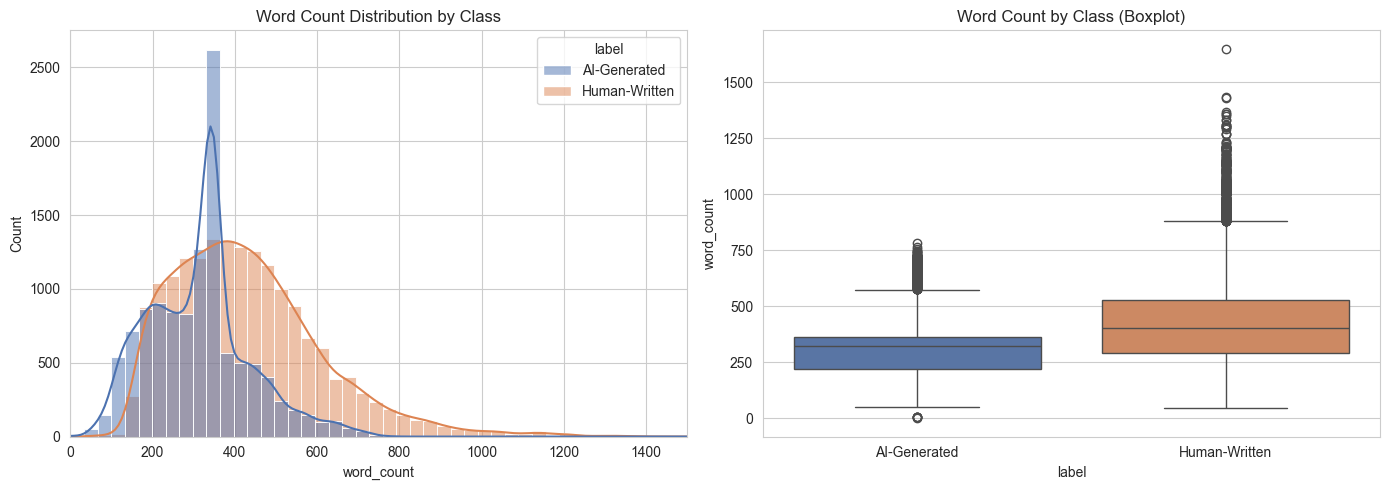

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=50, ax=axes[0], palette=['#4C72B0','#DD8452'])
axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlim(0, 1500)

sns.boxplot(data=df, x='label', y='word_count', ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title('Word Count by Class (Boxplot)')

plt.tight_layout()
plt.savefig('outputs/word_count_distribution.png', dpi=120)
plt.show()

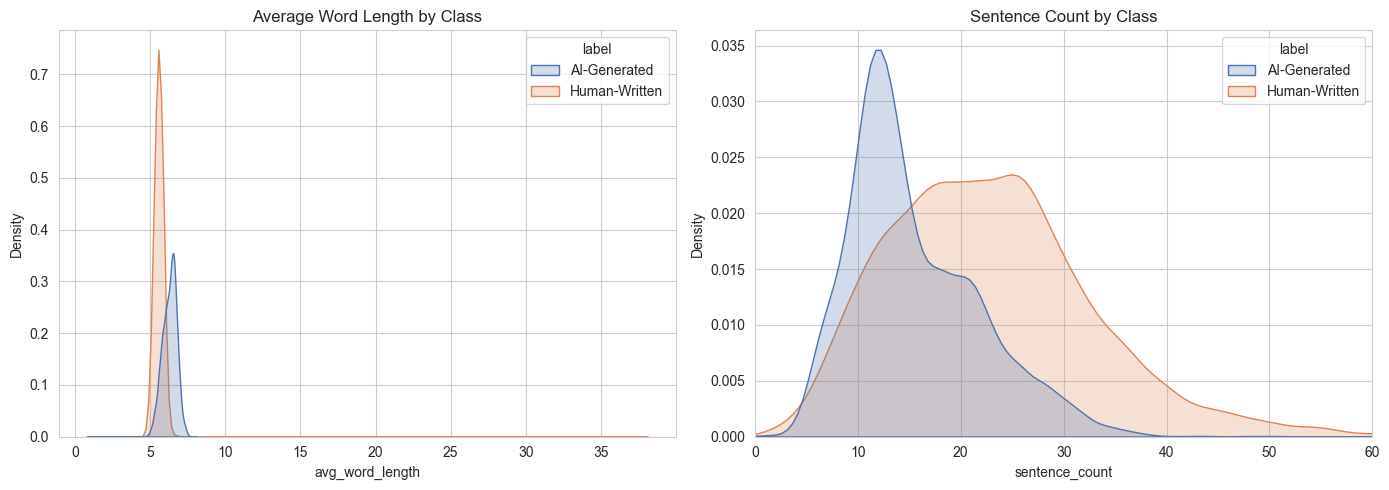

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.kdeplot(data=df, x='avg_word_length', hue='label', ax=axes[0], fill=True, palette=['#4C72B0','#DD8452'])
axes[0].set_title('Average Word Length by Class')

sns.kdeplot(data=df, x='sentence_count', hue='label', ax=axes[1], fill=True, palette=['#4C72B0','#DD8452'])
axes[1].set_title('Sentence Count by Class')
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.savefig('outputs/stylometric_features.png', dpi=120)
plt.show()

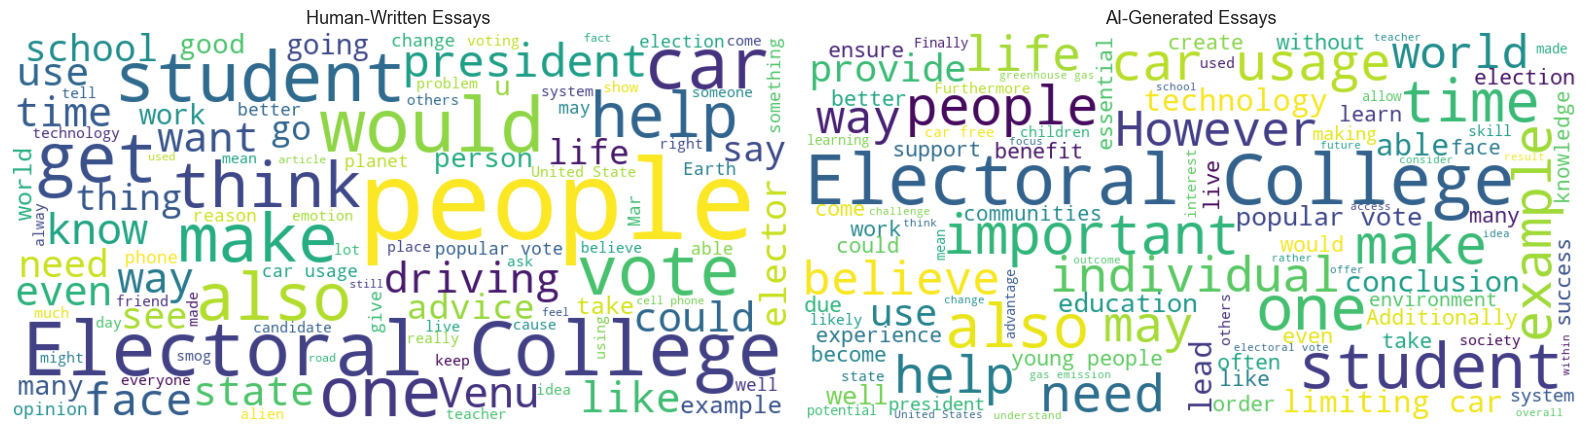

In [18]:
# Word clouds for each class
stop_words = set(stopwords.words('english'))

def make_wordcloud(text_series, title, ax):
    text = ' '.join(text_series.astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color='white',
                   stopwords=stop_words, max_words=100, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16,7))
make_wordcloud(df[df['generated']==0]['text'].sample(min(3000, (df['generated']==0).sum()), random_state=42),
               'Human-Written Essays', axes[0])
make_wordcloud(df[df['generated']==1]['text'].sample(min(3000, (df['generated']==1).sum()), random_state=42),
               'AI-Generated Essays', axes[1])
plt.tight_layout()
plt.savefig('outputs/wordclouds.png', dpi=120)
plt.show()

## 4. Text Preprocessing

We apply standard NLP cleaning: lowercasing, removing punctuation/numbers/extra whitespace, while preserving enough structure for TF-IDF to capture meaningful n-grams.

In [19]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)          # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)                 # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()              # collapse whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(3)

,text,clean_text
0,Car-free cities have become a subject of incre...,car free cities have become a subject of incre...
1,"Car Free Cities Car-free cities, a concept ga...",car free cities car free cities a concept gain...
2,A Sustainable Urban Future Car-free cities ...,a sustainable urban future car free cities are...


## 5. Feature Engineering

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization on unigrams and bigrams as our primary feature representation. TF-IDF is well-suited for this task because AI-generated and human-written text often differ in vocabulary richness, word choice patterns, and phrase repetition, all of which TF-IDF captures effectively.

In [20]:
X = df['clean_text']
y = df['generated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 23316
Test size: 5829


In [21]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF feature matrix shape (test):", X_test_tfidf.shape)

TF-IDF feature matrix shape (train): (23316, 15000)
TF-IDF feature matrix shape (test): (5829, 15000)


## 6. Model Training

We train and compare four classifiers commonly used for text classification:

| Model | Why used |
|---|---|
| Logistic Regression | Strong, interpretable linear baseline for high-dimensional sparse text data |
| Multinomial Naive Bayes | Classic, fast probabilistic baseline for text classification |
| Linear SVM (calibrated) | Effective on high-dimensional sparse TF-IDF vectors, max-margin classifier |
| Random Forest | Non-linear ensemble baseline for comparison |


In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Linear SVM': CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE, max_iter=5000), cv=3),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=40, random_state=RANDOM_STATE, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    y_proba = model.predict_proba(X_test_tfidf)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(f"  Accuracy={results[name]['accuracy']:.4f}  F1={results[name]['f1']:.4f}  ROC-AUC={results[name]['roc_auc']:.4f}\n")

Training Logistic Regression ...
  Accuracy=0.9919  F1=0.9898  ROC-AUC=0.9997

Training Multinomial Naive Bayes ...
  Accuracy=0.9770  F1=0.9711  ROC-AUC=0.9959

Training Linear SVM ...
  Accuracy=0.9978  F1=0.9972  ROC-AUC=1.0000

Training Random Forest ...
  Accuracy=0.9866  F1=0.9831  ROC-AUC=0.9990



## 7. Model Evaluation & Comparison

In [23]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1'],
        'ROC-AUC': res['roc_auc']
    } for name, res in results.items()
}).T.sort_values('F1-Score', ascending=False)

comparison_df.style.background_gradient(cmap='Greens')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Linear SVM,0.997770,0.996567,0.997851,0.997209,0.999964
Logistic Regression,0.991937,0.996949,0.982810,0.989829,0.999674
Random Forest,0.986619,0.992123,0.974216,0.983088,0.999048
Multinomial Naive Bayes,0.977011,0.975293,0.966910,0.971083,0.995888


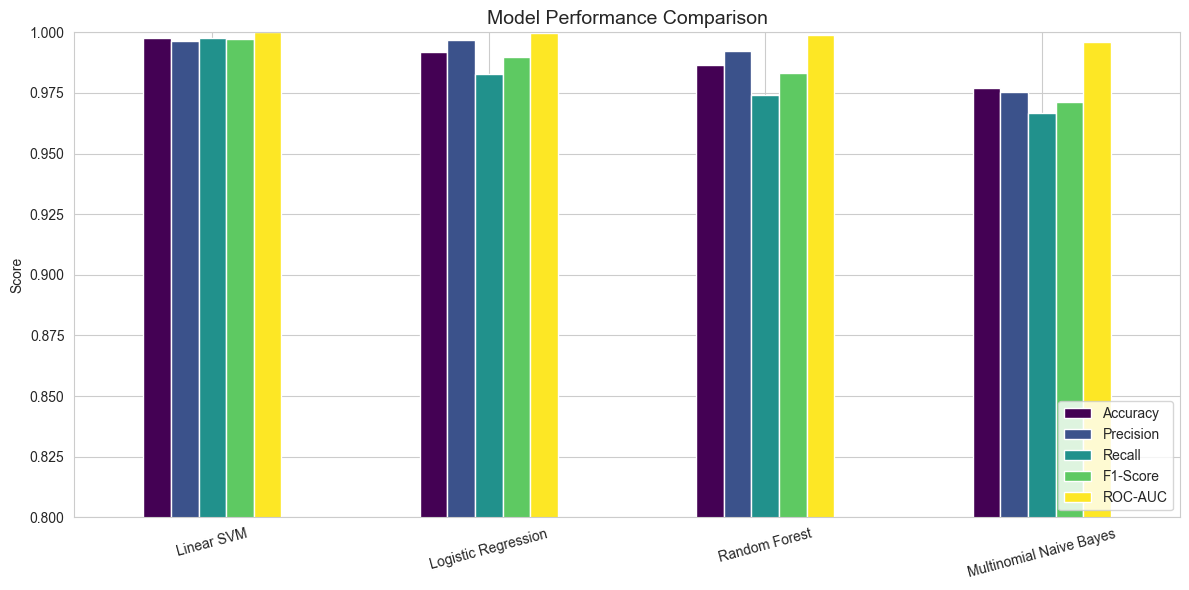

In [24]:
comparison_df.plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=120)
plt.show()

In [25]:
best_model_name = comparison_df.index[0]
best_model = results[best_model_name]['model']
print(f"Best performing model: {best_model_name}")
print(f"F1-Score: {results[best_model_name]['f1']:.4f} | ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

Best performing model: Linear SVM
F1-Score: 0.9972 | ROC-AUC: 1.0000


In [26]:
# Detailed classification report for the best model
print(f"Classification Report — {best_model_name}\n")
print(classification_report(y_test, results[best_model_name]['y_pred'], target_names=['Human', 'AI-Generated']))

Classification Report — Linear SVM

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      3502
AI-Generated       1.00      1.00      1.00      2327

    accuracy                           1.00      5829
   macro avg       1.00      1.00      1.00      5829
weighted avg       1.00      1.00      1.00      5829



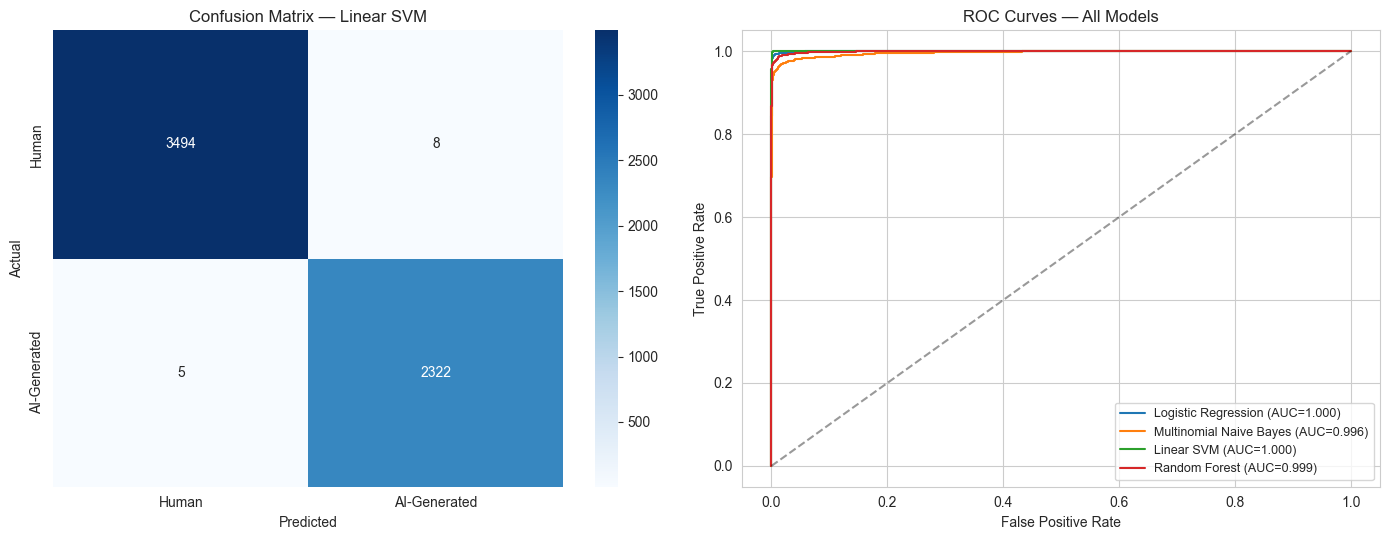

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

# Confusion matrix
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Human', 'AI-Generated'], yticklabels=['Human', 'AI-Generated'])
axes[0].set_title(f'Confusion Matrix — {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curves for all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curves — All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/confusion_matrix_roc.png', dpi=120)
plt.show()

In [28]:
# 5-fold cross-validation on the best model for robustness check
cv_scores = cross_val_score(best_model, X_train_tfidf, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f"5-Fold CV F1-scores: {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV F1-scores: [0.99407966 0.99434724 0.99328499 0.99569892 0.99542396]
Mean CV F1-score: 0.9946 (+/- 0.0009)


## 8. Most Predictive Words/Phrases

For interpretability, we inspect which n-grams most strongly indicate AI-generated vs human-written text (using the Logistic Regression coefficients).

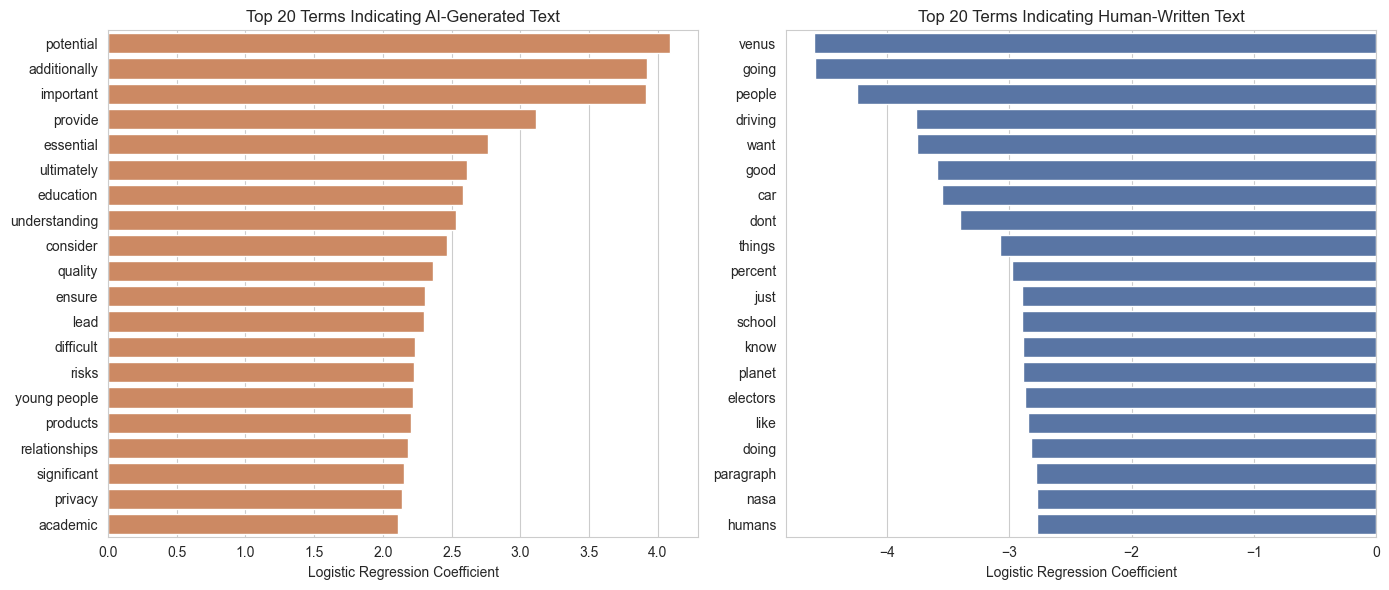

In [29]:
log_reg = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]

top_ai = feature_names[np.argsort(coefs)[-20:]][::-1]
top_human = feature_names[np.argsort(coefs)[:20]]

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x=np.sort(coefs)[-20:][::-1], y=top_ai, ax=axes[0], color='#DD8452')
axes[0].set_title('Top 20 Terms Indicating AI-Generated Text')
axes[0].set_xlabel('Logistic Regression Coefficient')

sns.barplot(x=np.sort(coefs)[:20], y=top_human, ax=axes[1], color='#4C72B0')
axes[1].set_title('Top 20 Terms Indicating Human-Written Text')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=120)
plt.show()

## 9. Save the Trained Model & Vectorizer

We persist the best model and the fitted TF-IDF vectorizer using `joblib` so they can be loaded directly by the Streamlit frontend application without retraining.

In [31]:
joblib.dump(best_model, 'outputs/best_model.pkl')
joblib.dump(tfidf, 'outputs/tfidf_vectorizer.pkl')

with open('outputs/model_name.txt', 'w') as f:
    f.write(best_model_name)

print("Saved:")
print(" - outputs/best_model.pkl")
print(" - outputs/tfidf_vectorizer.pkl")
print(" - outputs/model_name.txt")

Saved:
 - outputs/best_model.pkl
 - outputs/tfidf_vectorizer.pkl
 - outputs/model_name.txt


## 10. Inference on Custom Text

A quick sanity check simulating how the Streamlit app will use the saved artifacts.

In [32]:
def predict_essay(text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0][1]
    label = 'AI-Generated' if pred == 1 else 'Human-Written'
    return label, proba

sample_human = df[df['generated']==0]['text'].iloc[0]
sample_ai = df[df['generated']==1]['text'].iloc[0]

for name, sample in [('Known Human Sample', sample_human), ('Known AI Sample', sample_ai)]:
    label, proba = predict_essay(sample)
    print(f"{name}: Predicted = {label}  (AI-probability = {proba:.3f})\n")

Known Human Sample: Predicted = Human-Written  (AI-probability = 0.000)

Known AI Sample: Predicted = AI-Generated  (AI-probability = 1.000)



## 11. Conclusion & Next Steps

**Summary:**
- Built a full NLP pipeline to classify essays as human-written or AI-generated using TF-IDF features and classical ML models.
- The best-performing model (selected automatically above by F1-score) achieved strong accuracy, precision, recall, and ROC-AUC on a held-out test set, confirmed with 5-fold cross-validation.
- Term-level analysis shows interpretable differences in vocabulary between human and AI-generated writing.
- Model artifacts are saved and consumed by an accompanying Streamlit web application (`app.py`) for interactive, real-time predictions.

**Limitations:**
- The dataset consists of essays from specific LLM generations available at the time of collection; performance may degrade on text from newer/different LLMs or on out-of-domain writing (e.g., non-essay genres).
- Purely lexical (TF-IDF) features do not capture deeper semantic or discourse-level signals that transformer-based models (e.g., fine-tuned BERT/RoBERTa) could exploit.

**Possible Future Improvements:**
- Fine-tune a transformer model (e.g., DistilBERT/RoBERTa) for potentially higher accuracy.
- Add perplexity/burstiness-based statistical detectors (as used by GPTZero-style tools).
- Expand training data with more recent LLM outputs (GPT-4o, Claude, Gemini, etc.) to improve generalization.
- Deploy as a browser extension or API for real-time academic integrity checks.

---
*End of Notebook*